# Notebook 1 - Data Ingestion, Validation, and Subset Creation

This notebook prepares the raw CICIoT2023 files for the rest of the project. We load the CSV files, check that they match, clean obvious data issues, inspect the class balance, and save a smaller cleaned subset for preprocessing and model training.

# Step 0 - Imports

Load the libraries used for file handling, data analysis, and plotting. Keeping imports in one cell makes the notebook easier to rerun and debug.

The code below imports pandas/numpy for data work, matplotlib/seaborn for plots, and pathlib for safer paths.

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Step 1 - Define File Paths

Set the project folders once so the notebook does not depend on one person's machine path. All later reads and writes use these variables.

The code below detects the project root, creates the needed folder variables, and prints them so we can verify the paths.

In [5]:
_cwd = Path.cwd()
if (_cwd / "data").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "data").exists():
    PROJECT_ROOT = _cwd.parent
else:
    raise RuntimeError(f"Cannot locate project root from {_cwd}. "
                       "Open the notebook from inside the project folder.")

RAW_DIR    = PROJECT_ROOT / "data" / "raw" / "MERGED_CSV"
SUBSET_DIR = PROJECT_ROOT / "data" / "subset"

SUBSET_DIR.mkdir(parents=True, exist_ok=True)

print("Project root  :", PROJECT_ROOT)
print("Raw data dir  :", RAW_DIR)
print("Subset dir    :", SUBSET_DIR)

Project root  : c:\Users\user\Desktop\MyFiles\Uni\My_ML_Project
Raw data dir  : c:\Users\user\Desktop\MyFiles\Uni\My_ML_Project\data\raw\MERGED_CSV
Subset dir    : c:\Users\user\Desktop\MyFiles\Uni\My_ML_Project\data\subset


# Step 2 - List All CSV Files

Find the raw dataset files before loading them. This confirms that the expected CSVs are present and gives us a quick count of what will be merged.

The code below collects every raw CSV path and prints a preview of the files found.

In [6]:
csv_files = sorted(RAW_DIR.glob("*.csv"))

print(f"Found {len(csv_files)} CSV files.")
for f in csv_files[:10]:
    print("-", f.name)

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {RAW_DIR}")

Found 63 CSV files.
- Merged01.csv
- Merged02.csv
- Merged03.csv
- Merged04.csv
- Merged05.csv
- Merged06.csv
- Merged07.csv
- Merged08.csv
- Merged09.csv
- Merged10.csv


# Step 3 - Schema Consistency Check

Before combining files, we check that every CSV has the same columns in the same order. If one file has a different schema, merging first would create bad rows or missing values.

The code below reads only the headers first, then groups files by their column layout.

In [7]:
schema_map = {}

for file_path in csv_files:
    cols = tuple(pd.read_csv(file_path, nrows=0).columns)
    schema_map.setdefault(cols, []).append(file_path.name)

print(f"Number of unique schemas found: {len(schema_map)}")

for i, (cols, files) in enumerate(schema_map.items(), start=1):
    print(f"\nSchema {i}:")
    print(f"- Number of columns: {len(cols)}")
    print(f"- Example files: {files[:5]}")

Number of unique schemas found: 1

Schema 1:
- Number of columns: 40
- Example files: ['Merged01.csv', 'Merged02.csv', 'Merged03.csv', 'Merged04.csv', 'Merged05.csv']


# Step 4 - Load and Merge All CSV Files

Load each raw CSV and stack them into one DataFrame. We also keep the source filename so we can trace rows back if something looks unusual later.

The code below loops through the CSVs, loads each one, adds its source file name, and concatenates everything into `df`.

In [8]:
dfs = []

for i, file_path in enumerate(csv_files, start=1):
    df_part = pd.read_csv(file_path)
    dfs.append(df_part)
    print(f"[{i}/{len(csv_files)}] Loaded {file_path.name} -> shape {df_part.shape}")

df = pd.concat(dfs, ignore_index=True)

print("\nMerged dataset shape:", df.shape)

[1/63] Loaded Merged01.csv -> shape (712311, 40)
[2/63] Loaded Merged02.csv -> shape (748585, 40)
[3/63] Loaded Merged03.csv -> shape (697289, 40)
[4/63] Loaded Merged04.csv -> shape (676620, 40)
[5/63] Loaded Merged05.csv -> shape (744804, 40)
[6/63] Loaded Merged06.csv -> shape (718229, 40)
[7/63] Loaded Merged07.csv -> shape (702212, 40)
[8/63] Loaded Merged08.csv -> shape (712220, 40)
[9/63] Loaded Merged09.csv -> shape (678882, 40)
[10/63] Loaded Merged10.csv -> shape (916190, 40)
[11/63] Loaded Merged11.csv -> shape (909761, 40)
[12/63] Loaded Merged12.csv -> shape (896941, 40)
[13/63] Loaded Merged13.csv -> shape (709937, 40)
[14/63] Loaded Merged14.csv -> shape (902920, 40)
[15/63] Loaded Merged15.csv -> shape (718483, 40)
[16/63] Loaded Merged16.csv -> shape (765369, 40)
[17/63] Loaded Merged17.csv -> shape (731532, 40)
[18/63] Loaded Merged18.csv -> shape (714063, 40)
[19/63] Loaded Merged19.csv -> shape (701978, 40)
[20/63] Loaded Merged20.csv -> shape (719927, 40)
[21/63] L

In [9]:
#Clean up for mem usage
del dfs
if "df_part" in globals():
    del df_part

import gc
gc.collect()

print("Deleted temporary merge objects: dfs, df_part")


Deleted temporary merge objects: dfs, df_part


In [10]:
df.head(5)

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
0,19.92,6,63.36,25893.962218,0.0,0.0,0.0,0.99,0.99,0.0,...,6421.0,60.0,481.0,64.21,42.100000,64.21,0.000039,100.0,1772.410000,DDOS-PSHACK_FLOOD
1,0.00,47,64.00,3703.841331,0.0,0.0,0.0,0.00,0.00,0.0,...,57320.0,98.0,578.0,573.20,48.000000,573.20,0.000271,100.0,2304.000000,MIRAI-GREIP_FLOOD
2,7.92,17,65.91,19673.095685,0.0,0.0,0.0,0.00,0.00,0.0,...,6010.0,60.0,70.0,60.10,1.000000,60.10,0.000057,100.0,1.000000,DOS-UDP_FLOOD
3,20.40,6,110.50,261.664826,0.1,0.0,0.3,0.20,0.40,0.0,...,2223.0,54.0,1500.0,222.30,451.596686,222.30,0.004766,10.0,203939.566667,DNS_SPOOFING
4,0.32,1,63.96,28944.199848,0.0,0.0,0.0,0.00,0.01,0.0,...,6006.0,60.0,66.0,60.06,0.600000,60.06,0.000035,100.0,0.360000,DDOS-ICMP_FLOOD


# Step 5 - Inspect the Merged Dataset

Print the shape, columns, and a few rows of the merged data. This is a quick check that the load worked and that the target column is present.

The code below prints the dataset shape, column list, first rows, and basic information summary.

In [11]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


Shape: (45019243, 40)

Columns:
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label']


# Step 6 - Data Type Audit

Check the data types of all columns. The features should mostly be numeric, while the label should stay categorical before encoding.

The code below builds a small dtype table and separates numeric from non-numeric columns.

In [12]:
print("=== DATA TYPE SUMMARY ===")
print(df.dtypes.value_counts())

dtype_table = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values
})

dtype_table

=== DATA TYPE SUMMARY ===
float64    38
int64       1
str         1
Name: count, dtype: int64


,column,dtype
0,Header_Length,float64
1,Protocol Type,int64
2,Time_To_Live,float64
3,Rate,float64
4,fin_flag_number,float64
5,syn_flag_number,float64
6,rst_flag_number,float64
7,psh_flag_number,float64
8,ack_flag_number,float64
9,ece_flag_number,float64


In [13]:
object_cols = df.select_dtypes(include=["object"]).columns.tolist()

object_audit = []

for col in object_cols:
    non_null = df[col].dropna()

    sample_values = non_null.astype(str).unique()[:5].tolist()
    python_types = non_null.map(type).value_counts().to_dict()

    converted = pd.to_numeric(non_null, errors="coerce")
    convertible_ratio = converted.notna().mean() * 100 if len(non_null) > 0 else np.nan

    object_audit.append({
        "column": col,
        "non_null_count": len(non_null),
        "n_unique": non_null.nunique(),
        "sample_values": sample_values,
        "python_types": python_types,
        "convertible_to_numeric_percent": round(convertible_ratio, 2)
    })

print("Object columns:")
print(object_cols)

object_audit_df = pd.DataFrame(object_audit)
object_audit_df

C:\Users\user\AppData\Local\Temp\ipykernel_17048\57550722.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=["object"]).columns.tolist()


Object columns:
['Label']


,column,non_null_count,n_unique,sample_values,python_types,convertible_to_numeric_percent
0,Label,45019234,34,"[DDOS-PSHACK_FLOOD, MIRAI-GREIP_FLOOD, DOS-UDP...",{<class 'str'>: 45019234},0.0


In [14]:
mixed_type_cols = []

for col in df.columns:
    non_null = df[col].dropna()
    if len(non_null) == 0:
        continue

    n_python_types = non_null.map(type).nunique()

    if n_python_types > 1:
        mixed_type_cols.append(col)

print(f"Columns with mixed Python types: {len(mixed_type_cols)}")
print(mixed_type_cols if mixed_type_cols else "None")

Columns with mixed Python types: 0
None


In [15]:
suspected_numeric_but_not = []

for col in object_cols:
    non_null = df[col].dropna()
    if len(non_null) == 0:
        continue

    converted = pd.to_numeric(non_null, errors="coerce")
    convertible_ratio = converted.notna().mean()

    if convertible_ratio >= 0.95:
        suspected_numeric_but_not.append(col)

print("Columns that may be numeric but were loaded as object:")
print(suspected_numeric_but_not if suspected_numeric_but_not else "None")

Columns that may be numeric but were loaded as object:
None


In [16]:
#Clean up for mem usage

to_delete = [
    "dtype_table",
    "object_cols",
    "object_audit",
    "object_audit_df",
    "mixed_type_cols",
    "suspected_numeric_but_not"
]

for var in to_delete:
    if var in globals():
        del globals()[var]

gc.collect()
print("Deleted schema/type audit intermediates.")

Deleted schema/type audit intermediates.


# Step 7 - Missing Values, NaN, and Infinity

Check for missing values and infinite values. These can break scaling, statistics, and model training, so we identify them before saving the cleaned dataset.

The code below counts missing values, checks infinities in numeric columns, and reports affected rows/features.

In [17]:
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values(by="missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
Variance,679,0.001508
Std,677,0.001504
Label,9,0.000020
Number,8,0.000018
Min,7,0.000016
Tot sum,7,0.000016
LLC,7,0.000016
IPv,7,0.000016
IAT,7,0.000016
Max,7,0.000016


In [18]:
missing_only = missing_summary[missing_summary["missing_count"] > 0]

print(f"Columns with at least one missing value: {len(missing_only)}")

Columns with at least one missing value: 36


In [19]:
rows_with_missing = df.isna().any(axis=1).sum()
rows_with_missing_percent = (rows_with_missing / len(df)) * 100

print("Rows containing at least one missing value:", rows_with_missing)
print(f"Percentage of rows containing at least one missing value: {rows_with_missing_percent:.4f}%")

Rows containing at least one missing value: 679
Percentage of rows containing at least one missing value: 0.0015%


In [20]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
inf_count = np.isinf(df[numeric_cols]).sum()
inf_percent = (inf_count / len(df)) * 100

inf_summary = pd.DataFrame({
    "inf_count": inf_count,
    "inf_percent": inf_percent
}).sort_values(by="inf_count", ascending=False)

inf_summary

,inf_count,inf_percent
Rate,991,0.002201
Protocol Type,0,0.000000
Header_Length,0,0.000000
Time_To_Live,0,0.000000
fin_flag_number,0,0.000000
syn_flag_number,0,0.000000
rst_flag_number,0,0.000000
psh_flag_number,0,0.000000
ack_flag_number,0,0.000000
ece_flag_number,0,0.000000


In [21]:
rows_with_inf = np.isinf(df[numeric_cols]).any(axis=1).sum()
rows_with_inf_percent = (rows_with_inf / len(df)) * 100

print("Rows containing at least one infinity:", rows_with_inf)
print(f"Percentage of rows containing at least one infinity: {rows_with_inf_percent:.4f}%")

Rows containing at least one infinity: 991
Percentage of rows containing at least one infinity: 0.0022%


In [22]:
numeric_nan_count = df[numeric_cols].isna().sum()
numeric_inf_count = np.isinf(df[numeric_cols]).sum()

invalid_numeric_summary = pd.DataFrame({
    "nan_count": numeric_nan_count,
    "inf_count": numeric_inf_count
})

invalid_numeric_summary["total_invalid"] = (
    invalid_numeric_summary["nan_count"] + invalid_numeric_summary["inf_count"]
)

invalid_numeric_summary["invalid_percent"] = (
    invalid_numeric_summary["total_invalid"] / len(df) * 100
)

invalid_numeric_summary = invalid_numeric_summary.sort_values(
    by="total_invalid", ascending=False
)

invalid_numeric_summary

,nan_count,inf_count,total_invalid,invalid_percent
Rate,0,991,991,0.002201
Variance,679,0,679,0.001508
Std,677,0,677,0.001504
Number,8,0,8,0.000018
AVG,7,0,7,0.000016
IPv,7,0,7,0.000016
LLC,7,0,7,0.000016
Max,7,0,7,0.000016
Tot size,7,0,7,0.000016
IAT,7,0,7,0.000016


In [23]:
#Clean up for mem usage
to_delete = [
    "missing_count",
    "missing_percent",
    "missing_summary",
    "missing_only",
    "rows_with_missing",
    "inf_count",
    "inf_percent",
    "inf_summary",
    "inf_only",
    "rows_with_inf",
    "numeric_nan_count",
    "invalid_numeric_summary"
]

for var in to_delete:
    if var in globals():
        del globals()[var]

gc.collect()
print("Deleted missing/inf audit intermediates.")

Deleted missing/inf audit intermediates.


# Step 8 - Duplicate Row Analysis

Look for exact duplicate rows. Duplicates can make the dataset look larger than it really is and can bias training if repeated samples dominate a class.

The code below counts exact duplicates overall and per class so we can see where repetition is concentrated.

In [24]:
TARGET_COL = "Label"

assert TARGET_COL in df.columns, (
    f"Target column '{TARGET_COL}' not found. "
    f"Available columns: {df.columns.tolist()}"
)

n_total = len(df)

print(f"Target column: {TARGET_COL}")
print(f"Total rows: {n_total:,}")

Target column: Label
Total rows: 45,019,243


In [25]:
n_dupes = df.duplicated().sum()
dupe_pct = (n_dupes / n_total) * 100

print("=== EXACT DUPLICATE AUDIT ===")
print(f"Total rows           : {n_total:,}")
print(f"Exact duplicate rows : {n_dupes:,} ({dupe_pct:.4f}%)")
print(f"Unique rows          : {n_total - n_dupes:,}")

=== EXACT DUPLICATE AUDIT ===
Total rows           : 45,019,243
Exact duplicate rows : 24,013,983 (53.3416%)
Unique rows          : 21,005,260


In [26]:
per_class_dupe = []

for label, group in df.groupby(TARGET_COL, dropna=False):
    total = len(group)
    duplicates = group.duplicated().sum()
    dupe_pct_class = (duplicates / total) * 100 if total > 0 else 0.0

    per_class_dupe.append({
        "class": label,
        "total": total,
        "duplicates": duplicates,
        "dupe_pct": round(dupe_pct_class, 4)
    })

per_class_dupe = pd.DataFrame(per_class_dupe).sort_values("dupe_pct", ascending=False)
per_class_dupe

,class,total,duplicates,dupe_pct
6,DDOS-ICMP_FLOOD,6893259,4985687,72.3270
9,DDOS-RSTFINFLOOD,3872808,2617012,67.5740
11,DDOS-SYNONYMOUSIP_FLOOD,3445659,2274271,66.0039
13,DDOS-TCP_FLOOD,4306086,2745436,63.7571
14,DDOS-UDP_FLOOD,5181027,3216938,62.0907
8,DDOS-PSHACK_FLOOD,3920372,2278458,58.1184
20,DOS-TCP_FLOOD,2558256,1438053,56.2122
12,DDOS-SYN_FLOOD,3886130,2121493,54.5914
21,DOS-UDP_FLOOD,3177323,1326016,41.7337
19,DOS-SYN_FLOOD,1942176,803542,41.3733


In [27]:
exact_dupe_mask = df.duplicated(keep=False)
exact_dupes = df[exact_dupe_mask]

print("Rows that belong to exact-duplicate groups:", len(exact_dupes))
exact_dupes.head(10)

Rows that belong to exact-duplicate groups: 25996576


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
5,20.0,6,64.0,47281.073160,0.0,0.0,0.0,0.0,0.0,0.0,...,6000.0,60.0,60.0,60.0,0.0,60.0,0.000021,100.0,0.0,DDOS-TCP_FLOOD
6,20.0,6,64.0,99698.217257,0.0,0.0,0.0,1.0,1.0,0.0,...,6000.0,60.0,60.0,60.0,0.0,60.0,0.000010,100.0,0.0,DDOS-PSHACK_FLOOD
8,8.0,17,64.0,43518.406308,0.0,0.0,0.0,0.0,0.0,0.0,...,6000.0,60.0,60.0,60.0,0.0,60.0,0.000023,100.0,0.0,DDOS-UDP_FLOOD
9,52.0,6,64.0,322638.769231,0.0,0.0,0.0,0.0,1.0,0.0,...,860.0,86.0,86.0,86.0,0.0,86.0,0.000003,10.0,0.0,MITM-ARPSPOOFING
10,20.0,6,64.0,36494.422692,0.0,0.0,0.0,1.0,1.0,0.0,...,6000.0,60.0,60.0,60.0,0.0,60.0,0.000027,100.0,0.0,DDOS-PSHACK_FLOOD
11,20.0,6,64.0,32681.190588,0.0,1.0,0.0,0.0,0.0,0.0,...,6000.0,60.0,60.0,60.0,0.0,60.0,0.000031,100.0,0.0,DDOS-SYNONYMOUSIP_FLOOD
13,8.0,17,64.0,44582.312925,0.0,0.0,0.0,0.0,0.0,0.0,...,6000.0,60.0,60.0,60.0,0.0,60.0,0.000022,100.0,0.0,DDOS-UDP_FLOOD
14,20.0,6,64.0,30929.164516,0.0,1.0,0.0,0.0,0.0,0.0,...,6000.0,60.0,60.0,60.0,0.0,60.0,0.000032,100.0,0.0,DDOS-SYN_FLOOD
15,20.0,6,64.0,16680.469278,0.0,0.0,0.0,0.0,0.0,0.0,...,6000.0,60.0,60.0,60.0,0.0,60.0,0.000060,100.0,0.0,DOS-TCP_FLOOD
16,8.0,17,64.0,13080.629970,0.0,0.0,0.0,0.0,0.0,0.0,...,6000.0,60.0,60.0,60.0,0.0,60.0,0.000076,100.0,0.0,DDOS-UDP_FLOOD


In [28]:
exact_dupe_groups = df.groupby(list(df.columns), dropna=False).size()
exact_dupe_groups = exact_dupe_groups[exact_dupe_groups > 1]

print("Number of exact duplicate groups:", len(exact_dupe_groups))
exact_dupe_groups.head(10)

Number of exact duplicate groups: 1982593


Header_Length  Protocol Type  Time_To_Live  Rate           fin_flag_number  syn_flag_number  rst_flag_number  psh_flag_number  ack_flag_number  ece_flag_number  cwr_flag_number  ack_count  syn_count  fin_count  rst_count  HTTP  HTTPS  DNS  Telnet  SMTP  SSH  IRC  TCP  UDP  DHCP  ARP   ICMP  IGMP  IPv   LLC   Tot sum  Min   Max   AVG   Std  Tot size  IAT       Number  Variance  Label              
0.0            0              0.00          31045.921540   0.0              0.0              0.0              0.0              0.0              0.0              0.0              0.0        0.0        0.0        0.0        0.0   0.0    0.0  0.0     0.0   0.0  0.0  0.0  0.0  0.0   1.00  0.00  0.0   0.00  0.00  600.0    60.0  60.0  60.0  0.0  60.0      0.000032  10.0    0.0       RECON-HOSTDISCOVERY    2
                                            85423.706721   0.0              0.0              0.0              0.0              0.0              0.0              0.0              0.0        0.0   

In [29]:
feature_cols = [c for c in df.columns if c != TARGET_COL]

feature_dupes_mask = df.duplicated(subset=feature_cols, keep=False)
n_feature_dupe_rows = feature_dupes_mask.sum()

print("=== FEATURE-ONLY DUPLICATES ===")
print(f"Rows with identical feature vectors: {n_feature_dupe_rows:,}")

=== FEATURE-ONLY DUPLICATES ===
Rows with identical feature vectors: 26,465,709


In [30]:
if n_feature_dupe_rows > 0:
    feature_group_label_counts = (
        df.groupby(feature_cols, dropna=False)[TARGET_COL]
        .nunique()
    )

    conflicting_feature_groups = feature_group_label_counts[feature_group_label_counts > 1]
    n_conflicting = len(conflicting_feature_groups)
else:
    conflicting_feature_groups = pd.Series(dtype=int)
    n_conflicting = 0

print(f"Groups with conflicting labels: {n_conflicting:,}")

Groups with conflicting labels: 529,996


## Duplicate Rate per Class - Plot

This chart shows which classes contain the most duplicate rows. It helps decide whether duplicate removal affects all classes evenly or mainly a few labels.

The code below turns the duplicate-rate table into a sorted horizontal bar chart.

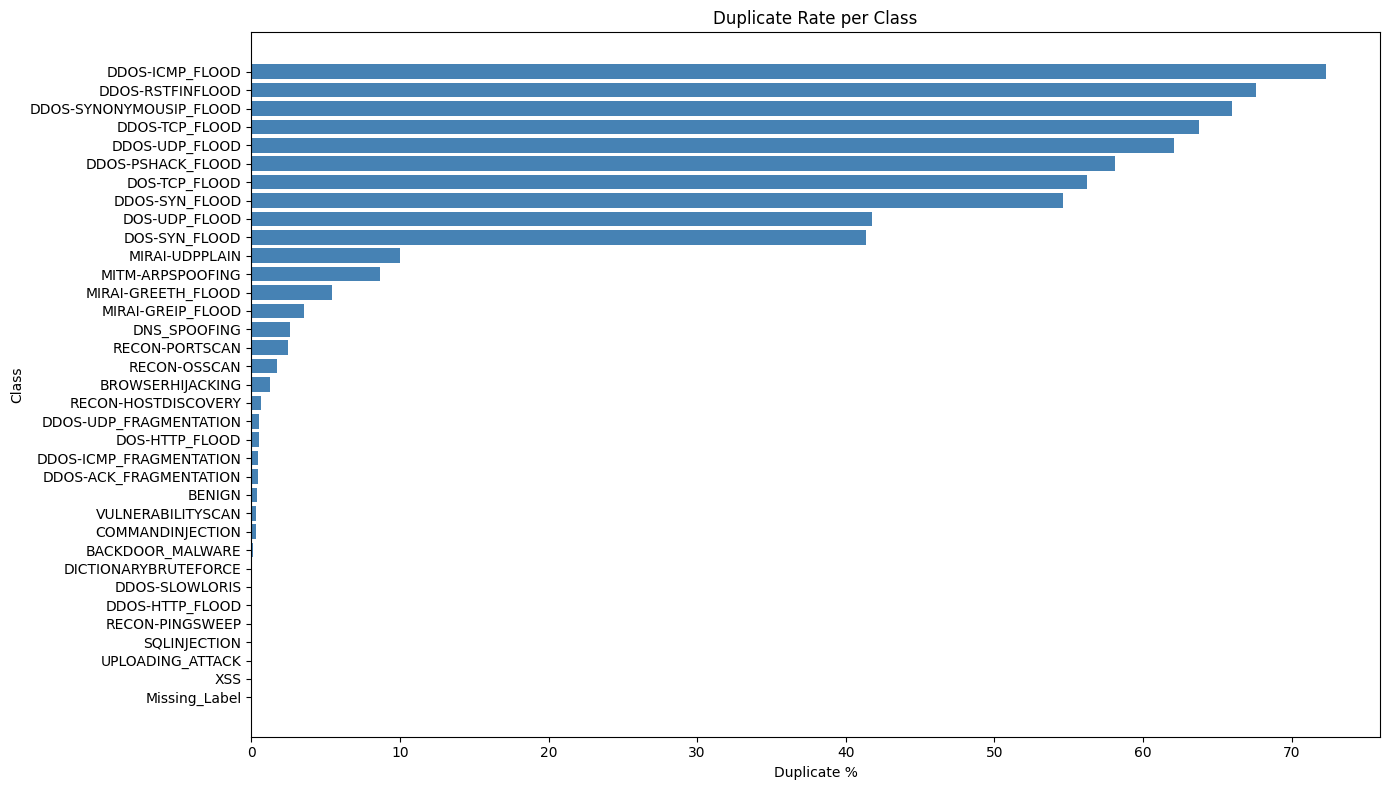

In [31]:
plot_class_labels = per_class_dupe["class"].fillna("Missing_Label").astype(str)
plot_dupe_pct = per_class_dupe["dupe_pct"]

plt.figure(figsize=(14, 8))
plt.barh(plot_class_labels[::-1], plot_dupe_pct[::-1], color="steelblue")
plt.xlabel("Duplicate %")
plt.ylabel("Class")
plt.title("Duplicate Rate per Class")
plt.tight_layout()
plt.show()

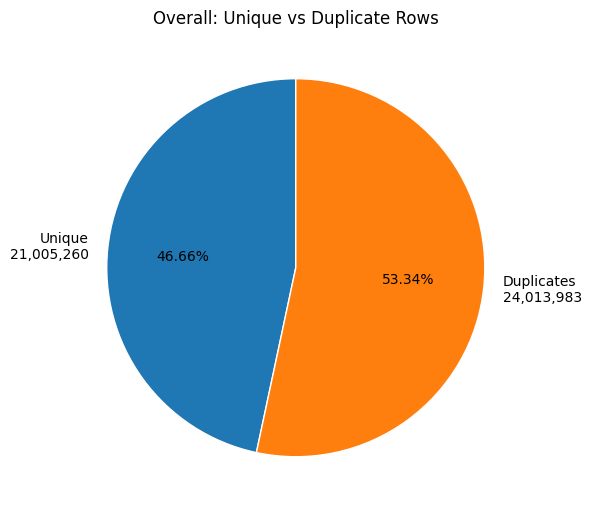

In [32]:
values = [n_total - n_dupes, n_dupes]
labels = [f"Unique\n{n_total - n_dupes:,}", f"Duplicates\n{n_dupes:,}"]

plt.figure(figsize=(6, 6))
plt.pie(
    values,
    labels=labels,
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)
plt.title("Overall: Unique vs Duplicate Rows")
plt.tight_layout()
plt.show()

In [33]:
print("Shape before removing dups: ",df.shape)
df=df.drop_duplicates()
print("Shape after removing dups: ",df.shape)

Shape before removing dups:  (45019243, 40)
Shape after removing dups:  (21005260, 40)


In [34]:
#Clean up for mem usage
to_delete = [
    "duplicate_rows_preview",
    "exact_dupe_mask",
    "exact_dupes",
    "exact_dupe_groups",
    "feature_dupes_mask",
    "feature_group_label_counts",
    "conflicting_feature_groups",
    "values",
    "labels"
]

for var in to_delete:
    if var in globals():
        del globals()[var]

gc.collect()
print("Deleted duplicate-analysis intermediates.")

Deleted duplicate-analysis intermediates.


# Clean Invalid Rows

Remove rows with NaN, infinite values, and exact duplicates. This gives us a cleaner base dataset for the rest of the notebook.

The code below builds masks for invalid rows, removes them, drops exact duplicates, and saves the cleaned full file.

In [35]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

nan_row_mask = df.isna().any(axis=1)
inf_row_mask = np.isinf(df[numeric_cols]).any(axis=1)

invalid_row_mask = nan_row_mask | inf_row_mask

print("Rows with at least one NaN:", nan_row_mask.sum())
print("Rows with at least one Inf:", inf_row_mask.sum())
print("Rows with NaN or Inf      :", invalid_row_mask.sum())
print(f"Percentage of dataset     : {(invalid_row_mask.mean() * 100):.4f}%")

Rows with at least one NaN: 409
Rows with at least one Inf: 577
Rows with NaN or Inf      : 586
Percentage of dataset     : 0.0028%


In [36]:
no_nan_inf_csv_path = SUBSET_DIR / "full_no_nan_inf.csv"

df.loc[~invalid_row_mask].to_csv(no_nan_inf_csv_path, index=False)

print("Original shape       :", df.shape)
print("Rows removed         :", invalid_row_mask.sum())
print("Rows kept            :", (~invalid_row_mask).sum())
print(f"Removal percentage   : {(invalid_row_mask.mean() * 100):.4f}%")
print("Saved cleaned dataset to:", no_nan_inf_csv_path)

Original shape       : (21005260, 40)
Rows removed         : 586
Rows kept            : 21004674
Removal percentage   : 0.0028%
Saved cleaned dataset to: c:\Users\user\Desktop\MyFiles\Uni\My_ML_Project\data\subset\full_no_nan_inf.csv


In [37]:
del df
del nan_row_mask
del inf_row_mask
del invalid_row_mask

gc.collect()

print("Deleted df and invalid-row masks from memory.")

Deleted df and invalid-row masks from memory.


# Load Cleaned Dataset

Reload the cleaned file so the next checks use the same saved version that later notebooks will depend on.

The code below reloads the cleaned CSV from disk and prints its shape.

In [38]:
df=pd.read_csv(SUBSET_DIR/"full_no_nan_inf.csv")
print("Reloaded cleaned dataset shape:", df.shape)

Reloaded cleaned dataset shape: (21004674, 40)


# Target/Class Distribution Analysis

Check how many rows each class has. This tells us how imbalanced the dataset is before we decide on a subset strategy.

The code below counts labels, computes percentages, and plots the class distribution.

In [39]:
TARGET_COL = "Label"

assert TARGET_COL in df.columns, (
    f"Target column '{TARGET_COL}' not found. "
    f"Available columns: {df.columns.tolist()}"
)

print(f"Target column: {TARGET_COL}")
print(f"Total records: {len(df):,}")

Target column: Label
Total records: 21,004,674


In [40]:
class_counts = df[TARGET_COL].value_counts(dropna=False).sort_values(ascending=False)
class_percent = (class_counts / len(df) * 100).round(4)

class_dist = pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values,
    "percentage": class_percent.values
})

print(f"Number of unique classes: {len(class_dist)}")
class_dist

Number of unique classes: 34


,class,count,percentage
0,DDOS-UDP_FLOOD,1964069,9.3506
1,DDOS-ICMP_FLOOD,1907549,9.0815
2,DOS-UDP_FLOOD,1851255,8.8135
3,DDOS-SYN_FLOOD,1764592,8.4009
4,DDOS-PSHACK_FLOOD,1641896,7.8168
5,DDOS-TCP_FLOOD,1560610,7.4298
6,DDOS-RSTFINFLOOD,1255783,5.9786
7,DDOS-SYNONYMOUSIP_FLOOD,1171372,5.5767
8,DOS-SYN_FLOOD,1138613,5.4208
9,DOS-TCP_FLOOD,1120179,5.3330


In [41]:
print("All classes:")
for cls in class_dist["class"].tolist():
    print("-", cls)

All classes:
- DDOS-UDP_FLOOD
- DDOS-ICMP_FLOOD
- DOS-UDP_FLOOD
- DDOS-SYN_FLOOD
- DDOS-PSHACK_FLOOD
- DDOS-TCP_FLOOD
- DDOS-RSTFINFLOOD
- DDOS-SYNONYMOUSIP_FLOOD
- DOS-SYN_FLOOD
- DOS-TCP_FLOOD
- BENIGN
- MIRAI-GREETH_FLOOD
- MIRAI-UDPPLAIN
- MIRAI-GREIP_FLOOD
- DDOS-ICMP_FRAGMENTATION
- VULNERABILITYSCAN
- DDOS-UDP_FRAGMENTATION
- DDOS-ACK_FRAGMENTATION
- MITM-ARPSPOOFING
- DNS_SPOOFING
- RECON-HOSTDISCOVERY
- RECON-OSSCAN
- RECON-PORTSCAN
- DOS-HTTP_FLOOD
- DDOS-HTTP_FLOOD
- DDOS-SLOWLORIS
- DICTIONARYBRUTEFORCE
- BROWSERHIJACKING
- COMMANDINJECTION
- SQLINJECTION
- XSS
- BACKDOOR_MALWARE
- RECON-PINGSWEEP
- UPLOADING_ATTACK


In [42]:
possible_benign = [
    cls for cls in class_dist["class"].astype(str)
    if "benign" in str(cls).lower().strip()
]

print("Possible benign class labels found:")
print(possible_benign if possible_benign else "None found")

BENIGN_LABEL = possible_benign[0] if possible_benign else None

print("Selected benign label:", BENIGN_LABEL)

Possible benign class labels found:
['BENIGN']
Selected benign label: BENIGN


In [43]:
if BENIGN_LABEL is not None:
    benign_mask = df[TARGET_COL].astype(str).str.lower().str.strip() == BENIGN_LABEL.lower().strip()
    n_benign = benign_mask.sum()
    n_attack = (~benign_mask).sum()

    benign_pct = n_benign / len(df) * 100
    attack_pct = n_attack / len(df) * 100

    print("=== BENIGN vs ATTACK ===")
    print(f"Benign records : {n_benign:,} ({benign_pct:.2f}%)")
    print(f"Attack records : {n_attack:,} ({attack_pct:.2f}%)")
    print(f"Attack / Benign ratio: {n_attack / max(n_benign, 1):.2f}")
else:
    print("Benign label not identified yet. Please set BENIGN_LABEL manually.")

=== BENIGN vs ATTACK ===
Benign records : 1,047,308 (4.99%)
Attack records : 19,957,366 (95.01%)
Attack / Benign ratio: 19.06


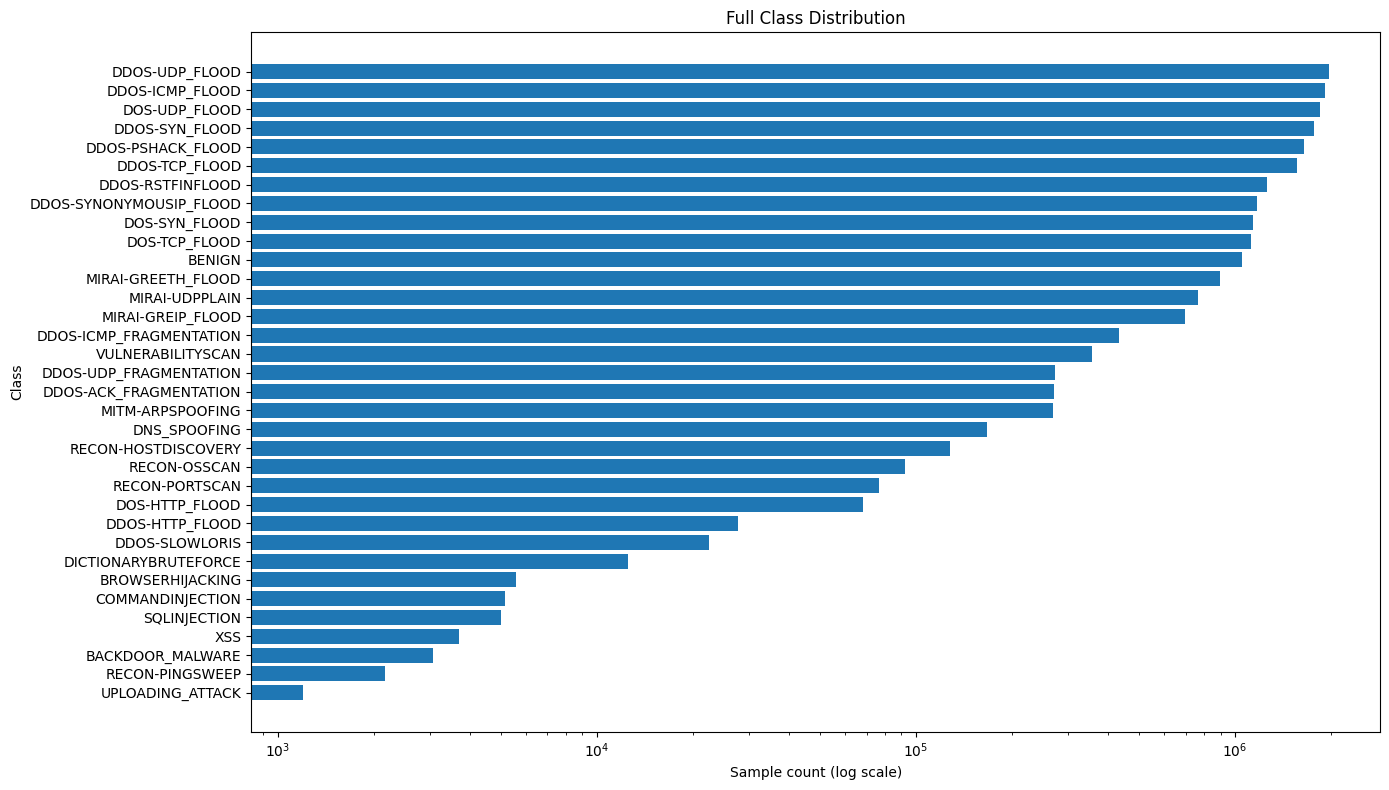

In [44]:
plt.figure(figsize=(14, 8))

plot_labels = class_dist["class"].fillna("Missing_Label").astype(str)
plot_counts = class_dist["count"]

plt.barh(plot_labels[::-1], plot_counts[::-1])
plt.xscale("log")
plt.xlabel("Sample count (log scale)")
plt.ylabel("Class")
plt.title("Full Class Distribution")
plt.tight_layout()
plt.show()

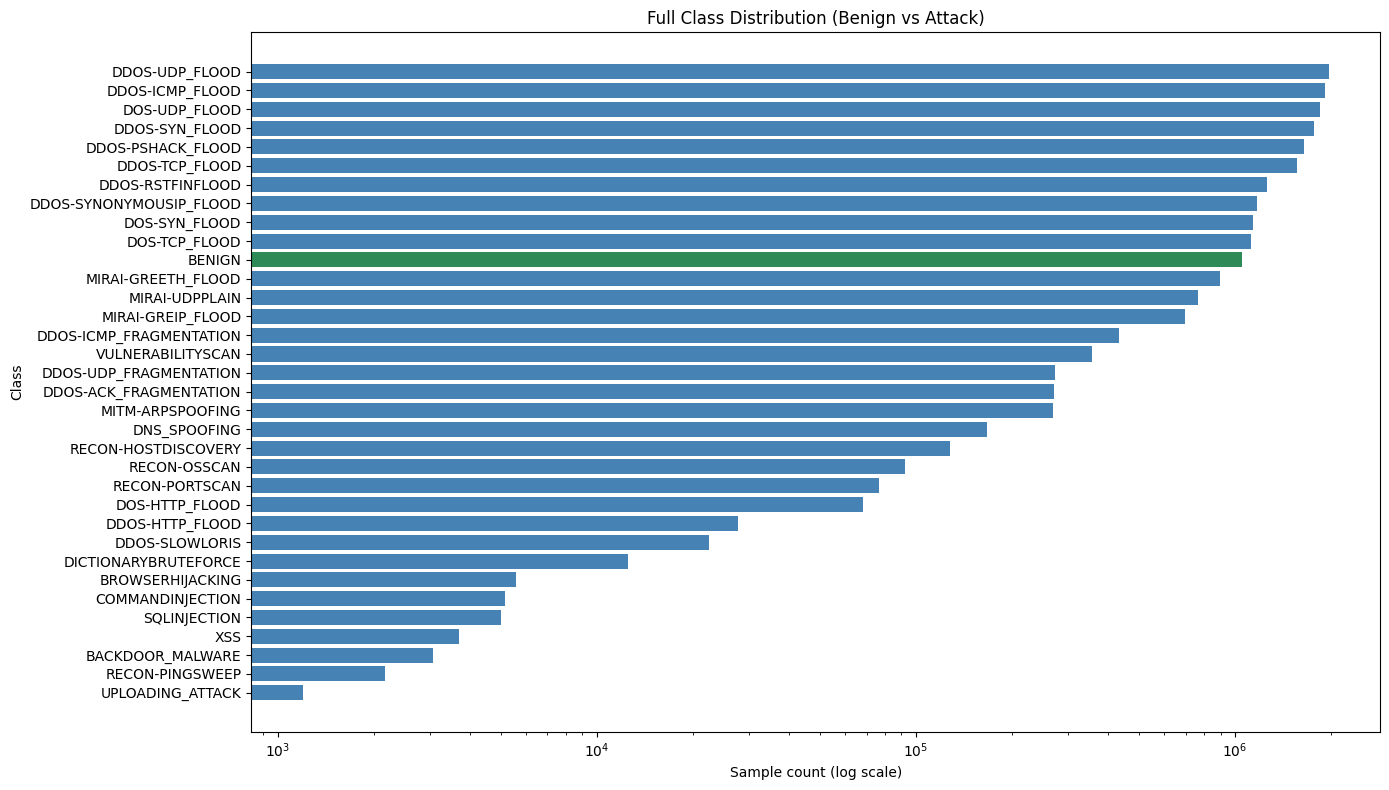

In [45]:
plot_labels = class_dist["class"].fillna("Missing_Label").astype(str)
plot_counts = class_dist["count"]

if BENIGN_LABEL is not None:
    colors = [
        "seagreen" if label.lower().strip() == str(BENIGN_LABEL).lower().strip() else "steelblue"
        for label in plot_labels
    ]
else:
    colors = ["steelblue"] * len(class_dist)

plt.figure(figsize=(14, 8))
plt.barh(plot_labels[::-1], plot_counts[::-1], color=colors[::-1])
plt.xscale("log")
plt.xlabel("Sample count (log scale)")
plt.ylabel("Class")
plt.title("Full Class Distribution (Benign vs Attack)")
plt.tight_layout()
plt.show()

In [46]:
#Clean up for mem usage
to_delete = [
    "class_counts",
    "class_percent",
    "possible_benign",
    "benign_mask",
    "n_benign",
    "n_attack",
    "benign_pct",
    "attack_pct"
]

for var in to_delete:
    if var in globals():
        del globals()[var]

gc.collect()
print("Deleted class distribution intermediates.")

Deleted class distribution intermediates.


In [47]:
TARGET_COL = "Label"

numeric_feature_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c != TARGET_COL
]

print(f"Numeric features selected for audit: {len(numeric_feature_cols)}")
print(numeric_feature_cols[:20])  # preview first 20

Numeric features selected for audit: 39
['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP']


# Step 9 - Constant and Near-Constant Feature Detection

Find features that barely change. These columns usually add little value to a model and can make analysis noisier.

The code below calculates unique-value counts and flags constant or near-constant numeric features.

In [48]:
TARGET_COL = "Label"

feature_cols = [c for c in df.columns if c != TARGET_COL]
numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Total feature columns   : {len(feature_cols)}")
print(f"Numeric feature columns : {len(numeric_cols)}")

Total feature columns   : 39
Numeric feature columns : 39


In [49]:
constant_cols = [c for c in numeric_cols if df[c].nunique(dropna=True) <= 1]

print("=== CONSTANT COLUMNS (nunique <= 1) ===")
print(f"Count: {len(constant_cols)}")

if constant_cols:
    print("Columns:")
    print(constant_cols)
else:
    print("None found.")

=== CONSTANT COLUMNS (nunique <= 1) ===
Count: 0
None found.


In [50]:
DOMINANCE_THRESHOLD = 0.995   # 99.5%

near_constant_info = []

for col in numeric_cols:
    value_freq = df[col].value_counts(normalize=True, dropna=False)

    if len(value_freq) == 0:
        continue

    top_freq = value_freq.iloc[0]

    if top_freq >= DOMINANCE_THRESHOLD:
        top_val = value_freq.index[0]

        near_constant_info.append({
            "column": col,
            "dominant_value": top_val,
            "dominant_pct": round(top_freq * 100, 4),
            "n_unique": df[col].nunique(dropna=True)
        })

near_constant_df = pd.DataFrame(near_constant_info)

if not near_constant_df.empty:
    near_constant_df = near_constant_df.sort_values(
        by="dominant_pct", ascending=False
    ).reset_index(drop=True)

print(f"=== NEAR-CONSTANT COLUMNS (dominant value >= {DOMINANCE_THRESHOLD*100:.1f}%) ===")
print(f"Count: {len(near_constant_df)}")

near_constant_df

=== NEAR-CONSTANT COLUMNS (dominant value >= 99.5%) ===
Count: 6


,column,dominant_value,dominant_pct,n_unique
0,cwr_flag_number,0.0,99.9336,39
1,IGMP,0.0,99.8584,38
2,ece_flag_number,0.0,99.8474,67
3,SMTP,0.0,99.8310,23
4,Telnet,0.0,99.8306,22
5,IRC,0.0,99.8005,34


In [51]:
safe_drop_candidates = sorted(constant_cols)
review_drop_candidates = sorted(near_constant_df["column"].tolist()) if not near_constant_df.empty else []

print("=== SAFE DROP CANDIDATES ===")
print(f"Count: {len(safe_drop_candidates)}")
print(safe_drop_candidates if safe_drop_candidates else "None")

print("\n=== REVIEW DROP CANDIDATES ===")
print(f"Count: {len(review_drop_candidates)}")
print(review_drop_candidates if review_drop_candidates else "None")

=== SAFE DROP CANDIDATES ===
Count: 0
None

=== REVIEW DROP CANDIDATES ===
Count: 6
['IGMP', 'IRC', 'SMTP', 'Telnet', 'cwr_flag_number', 'ece_flag_number']


# Step 10 - Numeric Feature Distribution Analysis

Summarize the numeric features with basic statistics, skewness, and variance. This helps us understand scale, spread, and whether transformations may be needed.

The code below creates a numeric summary table with mean, median, standard deviation, skewness, and variance.

In [52]:
stats = df[numeric_feature_cols].agg(["mean", "median", "std", "min", "max"]).T
stats.columns = ["mean", "median", "std", "min", "max"]

stats = stats.round(6)
stats.head(20)

,mean,median,std,min,max
Header_Length,14.023096,19.800000,9.086032,0.000000,60.0
Protocol Type,11.235802,6.000000,11.468861,0.000000,47.0
Time_To_Live,69.413409,64.000000,20.664339,0.000000,255.0
Rate,19238.420756,12682.341558,31067.842624,0.000013,15728640.0
fin_flag_number,0.061740,0.000000,0.234751,0.000000,1.0
syn_flag_number,0.195044,0.000000,0.384734,0.000000,1.0
rst_flag_number,0.074060,0.000000,0.245410,0.000000,1.0
psh_flag_number,0.093045,0.000000,0.258346,0.000000,1.0
ack_flag_number,0.168229,0.000000,0.336029,0.000000,1.0
ece_flag_number,0.000061,0.000000,0.002960,0.000000,1.0


In [53]:
quantiles = df[numeric_feature_cols].quantile([0.01, 0.25, 0.50, 0.75, 0.99]).T
quantiles.columns = ["q01", "q25", "q50", "q75", "q99"]

quantiles = quantiles.round(6)
quantiles.head(20)


,q01,q25,q50,q75,q99
Header_Length,0.000000,7.920000,19.800000,20.000000,32.000000
Protocol Type,1.000000,6.000000,6.000000,17.000000,47.000000
Time_To_Live,58.300000,64.000000,64.000000,65.730000,183.700000
Rate,42.694929,4502.886835,12682.341558,27299.557407,107188.959877
fin_flag_number,0.000000,0.000000,0.000000,0.000000,1.000000
syn_flag_number,0.000000,0.000000,0.000000,0.010000,1.000000
rst_flag_number,0.000000,0.000000,0.000000,0.000000,1.000000
psh_flag_number,0.000000,0.000000,0.000000,0.010000,1.000000
ack_flag_number,0.000000,0.000000,0.000000,0.030000,1.000000
ece_flag_number,0.000000,0.000000,0.000000,0.000000,0.000000


In [54]:
numeric_summary = stats.join(quantiles)
numeric_summary.head(20)

,mean,median,std,min,max,q01,q25,q50,q75,q99
Header_Length,14.023096,19.800000,9.086032,0.000000,60.0,0.000000,7.920000,19.800000,20.000000,32.000000
Protocol Type,11.235802,6.000000,11.468861,0.000000,47.0,1.000000,6.000000,6.000000,17.000000,47.000000
Time_To_Live,69.413409,64.000000,20.664339,0.000000,255.0,58.300000,64.000000,64.000000,65.730000,183.700000
Rate,19238.420756,12682.341558,31067.842624,0.000013,15728640.0,42.694929,4502.886835,12682.341558,27299.557407,107188.959877
fin_flag_number,0.061740,0.000000,0.234751,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000
syn_flag_number,0.195044,0.000000,0.384734,0.000000,1.0,0.000000,0.000000,0.000000,0.010000,1.000000
rst_flag_number,0.074060,0.000000,0.245410,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000
psh_flag_number,0.093045,0.000000,0.258346,0.000000,1.0,0.000000,0.000000,0.000000,0.010000,1.000000
ack_flag_number,0.168229,0.000000,0.336029,0.000000,1.0,0.000000,0.000000,0.000000,0.030000,1.000000
ece_flag_number,0.000061,0.000000,0.002960,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000


In [55]:
skewness = df[numeric_feature_cols].skew(numeric_only=True)

numeric_summary["skewness"] = skewness.round(6)
numeric_summary.head(20)

,mean,median,std,min,max,q01,q25,q50,q75,q99,skewness
Header_Length,14.023096,19.800000,9.086032,0.000000,60.0,0.000000,7.920000,19.800000,20.000000,32.000000,-0.075729
Protocol Type,11.235802,6.000000,11.468861,0.000000,47.0,1.000000,6.000000,6.000000,17.000000,47.000000,2.175887
Time_To_Live,69.413409,64.000000,20.664339,0.000000,255.0,58.300000,64.000000,64.000000,65.730000,183.700000,5.270693
Rate,19238.420756,12682.341558,31067.842624,0.000013,15728640.0,42.694929,4502.886835,12682.341558,27299.557407,107188.959877,59.471855
fin_flag_number,0.061740,0.000000,0.234751,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,3.689215
syn_flag_number,0.195044,0.000000,0.384734,0.000000,1.0,0.000000,0.000000,0.000000,0.010000,1.000000,1.541635
rst_flag_number,0.074060,0.000000,0.245410,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,3.312767
psh_flag_number,0.093045,0.000000,0.258346,0.000000,1.0,0.000000,0.000000,0.000000,0.010000,1.000000,2.887978
ack_flag_number,0.168229,0.000000,0.336029,0.000000,1.0,0.000000,0.000000,0.000000,0.030000,1.000000,1.756092
ece_flag_number,0.000061,0.000000,0.002960,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,107.048130


In [56]:
def classify_skew(s):
    a = abs(s)
    if a > 10:
        return "extreme"
    elif a > 1:
        return "high"
    elif a > 0.5:
        return "moderate"
    else:
        return "symmetric"

numeric_summary["skew_tier"] = numeric_summary["skewness"].apply(classify_skew)

skew_tier_counts = numeric_summary["skew_tier"].value_counts()

print("=== SKEWNESS TIER SUMMARY ===")
print(skew_tier_counts)

numeric_summary.head(20)

=== SKEWNESS TIER SUMMARY ===
skew_tier
high         22
extreme      15
symmetric     2
Name: count, dtype: int64


,mean,median,std,min,max,q01,q25,q50,q75,q99,skewness,skew_tier
Header_Length,14.023096,19.800000,9.086032,0.000000,60.0,0.000000,7.920000,19.800000,20.000000,32.000000,-0.075729,symmetric
Protocol Type,11.235802,6.000000,11.468861,0.000000,47.0,1.000000,6.000000,6.000000,17.000000,47.000000,2.175887,high
Time_To_Live,69.413409,64.000000,20.664339,0.000000,255.0,58.300000,64.000000,64.000000,65.730000,183.700000,5.270693,high
Rate,19238.420756,12682.341558,31067.842624,0.000013,15728640.0,42.694929,4502.886835,12682.341558,27299.557407,107188.959877,59.471855,extreme
fin_flag_number,0.061740,0.000000,0.234751,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,3.689215,high
syn_flag_number,0.195044,0.000000,0.384734,0.000000,1.0,0.000000,0.000000,0.000000,0.010000,1.000000,1.541635,high
rst_flag_number,0.074060,0.000000,0.245410,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,1.000000,3.312767,high
psh_flag_number,0.093045,0.000000,0.258346,0.000000,1.0,0.000000,0.000000,0.000000,0.010000,1.000000,2.887978,high
ack_flag_number,0.168229,0.000000,0.336029,0.000000,1.0,0.000000,0.000000,0.000000,0.030000,1.000000,1.756092,high
ece_flag_number,0.000061,0.000000,0.002960,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,107.048130,extreme


In [57]:
EXTREME_RATIO_THRESHOLD = 10.0

extreme_mask = (
    (numeric_summary["q99"] != 0) &
    ((numeric_summary["max"].abs() / numeric_summary["q99"].abs().replace(0, np.nan)) > EXTREME_RATIO_THRESHOLD)
)

suspicious_extremes = numeric_summary[extreme_mask].copy()

if not suspicious_extremes.empty:
    suspicious_extremes["max_to_q99_ratio"] = (
        suspicious_extremes["max"].abs() / suspicious_extremes["q99"].abs()
    ).round(2)

print(f"Suspicious extreme-value features: {len(suspicious_extremes)}")
suspicious_extremes[["min", "max", "q99", "max_to_q99_ratio"]].head(20)

Suspicious extreme-value features: 7


,min,max,q99,max_to_q99_ratio
Rate,0.000013,1.572864e+07,1.071890e+05,146.74
DHCP,0.000000,8.000000e-01,1.000000e-02,80.00
Min,42.000000,7.306000e+03,5.920000e+02,12.34
Max,46.000000,5.219400e+04,3.492000e+03,14.95
Std,0.000000,1.165540e+04,1.119788e+03,10.41
IAT,-0.017818,7.861200e+04,2.588500e-02,3036971.37
Variance,0.000000,1.358485e+08,1.253924e+06,108.34


In [58]:
ZERO_INFLATION_THRESHOLD = 0.50

zero_pct = (df[numeric_feature_cols] == 0).mean()
zero_inflated = zero_pct[zero_pct >= ZERO_INFLATION_THRESHOLD].sort_values(ascending=False)

zero_inflated_df = pd.DataFrame({
    "column": zero_inflated.index,
    "zero_pct": (zero_inflated.values * 100).round(2)
})

print(f"Zero-inflated columns (>= {ZERO_INFLATION_THRESHOLD*100:.0f}% zeros): {len(zero_inflated_df)}")
zero_inflated_df.head(20)

Zero-inflated columns (>= 50% zeros): 23


,column,zero_pct
0,cwr_flag_number,99.93
1,IGMP,99.86
2,ece_flag_number,99.85
3,SMTP,99.83
4,Telnet,99.83
5,IRC,99.80
6,SSH,99.34
7,DHCP,98.81
8,fin_flag_number,88.04
9,fin_count,88.04


In [59]:
variance_series = df[numeric_feature_cols].var().sort_values()

print("=== VARIANCE OVERVIEW ===")
print(f"Min variance   : {variance_series.min():.6f} ({variance_series.idxmin()})")
print(f"Median variance: {variance_series.median():.6f}")
print(f"Max variance   : {variance_series.max():.6f} ({variance_series.idxmax()})")

print("\nLowest-variance features:")
print(variance_series.head(10))

=== VARIANCE OVERVIEW ===
Min variance   : 0.000001 (Telnet)
Median variance: 0.148020
Max variance   : 320336603390.605042 (Variance)

Lowest-variance features:
Telnet             0.000001
SMTP               0.000001
IRC                0.000002
IGMP               0.000004
cwr_flag_number    0.000004
ece_flag_number    0.000009
DHCP               0.000049
SSH                0.000123
ARP                0.000732
IPv                0.000732
dtype: float64


## Skewness Distribution Plot

This plot highlights features with strong skew. Highly skewed features may need transformation later, especially for linear models and neural networks.

The code below sorts features by skewness and colors the bars based on how extreme the skew is.

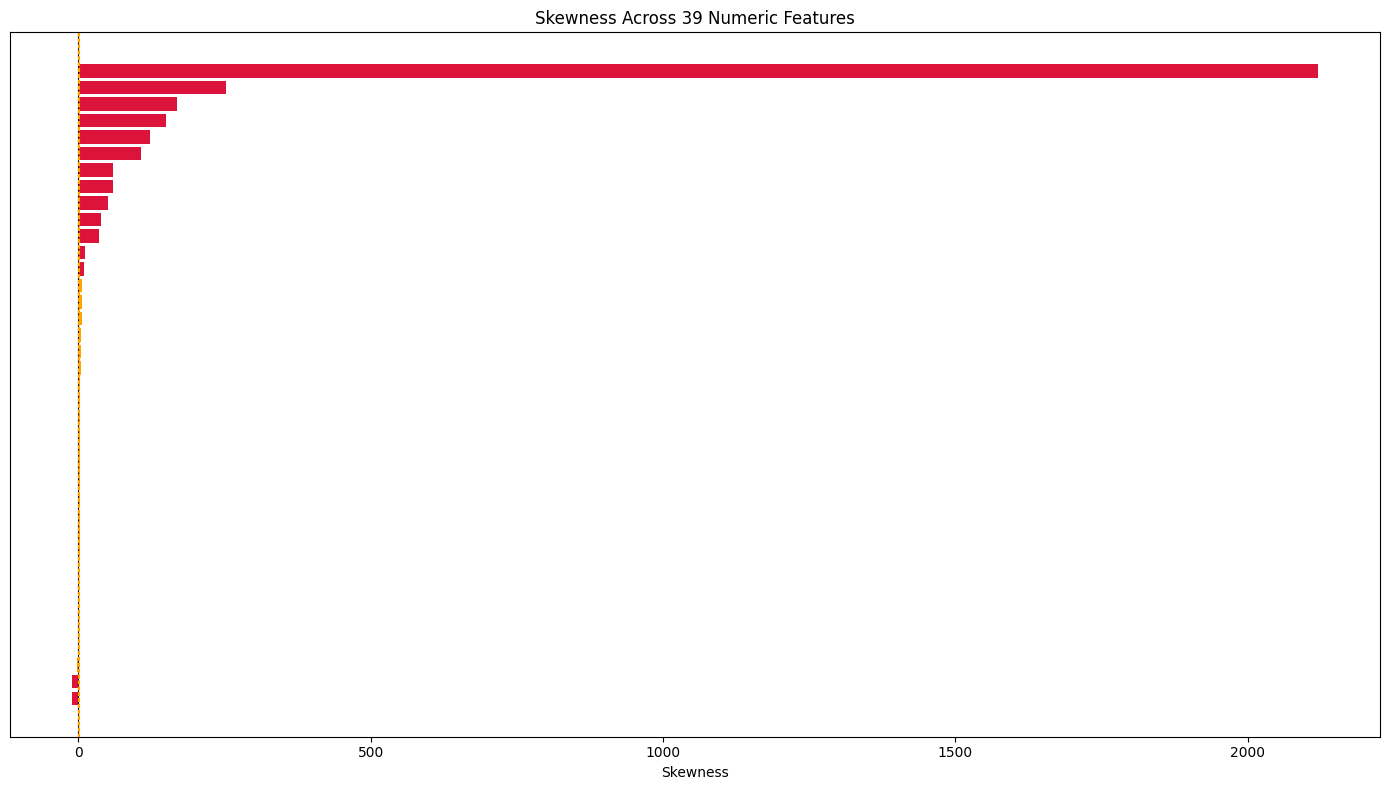

In [60]:
skew_sorted = numeric_summary["skewness"].sort_values()

colors = [
    "crimson" if abs(s) > 10 else
    "orange" if abs(s) > 1 else
    "goldenrod" if abs(s) > 0.5 else
    "steelblue"
    for s in skew_sorted
]

plt.figure(figsize=(14, 8))
plt.barh(range(len(skew_sorted)), skew_sorted.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.axvline(1, color="orange", linestyle="--", linewidth=0.8)
plt.axvline(-1, color="orange", linestyle="--", linewidth=0.8)
plt.xlabel("Skewness")
plt.title(f"Skewness Across {len(numeric_feature_cols)} Numeric Features")
plt.yticks([])
plt.tight_layout()
plt.show()

## Variance Distribution Plot

Feature variances can be very different in size, so the plot uses a log scale. This makes it easier to compare both small and very large variances.

The code below plots log-transformed variance values so very large ranges are still readable.

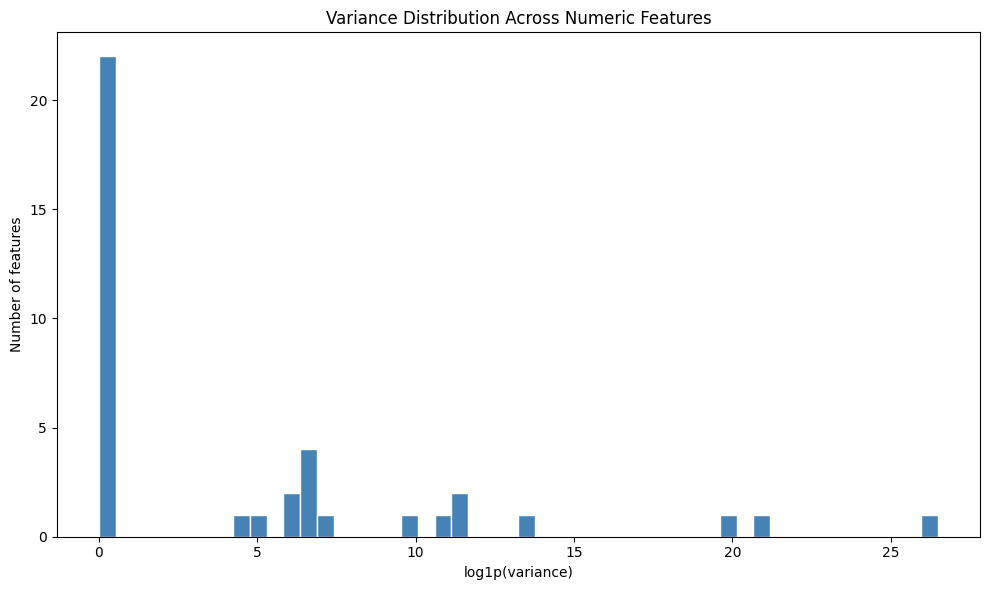

In [61]:
log_var = np.log1p(variance_series.values)

plt.figure(figsize=(10, 6))
plt.hist(log_var, bins=50, color="steelblue", edgecolor="white")
plt.xlabel("log1p(variance)")
plt.ylabel("Number of features")
plt.title("Variance Distribution Across Numeric Features")
plt.tight_layout()
plt.show()

In [62]:
print("=" * 60)
print("SUMMARY-NUMERIC FEATURE DISTRIBUTION")
print("=" * 60)
print(f"Numeric features audited        : {len(numeric_feature_cols)}")
print(f"Highly/extremely skewed         : {(numeric_summary['skew_tier'].isin(['high', 'extreme'])).sum()}")
print(f"Suspicious extreme-value cols   : {len(suspicious_extremes)}")
print(f"Zero-inflated columns           : {len(zero_inflated_df)}")
print("=" * 60)
print("This step provides global understanding of numeric feature behavior.")
print("No transformation decisions are being applied yet.")

SUMMARY-NUMERIC FEATURE DISTRIBUTION
Numeric features audited        : 39
Highly/extremely skewed         : 37
Suspicious extreme-value cols   : 7
Zero-inflated columns           : 23
This step provides global understanding of numeric feature behavior.
No transformation decisions are being applied yet.


# Step 11 - Lightweight Visualizations

Use sampled plots instead of plotting the full dataset. This keeps the notebook responsive while still showing useful distribution patterns.

The code below samples rows and plots histograms for the highest-variance features.

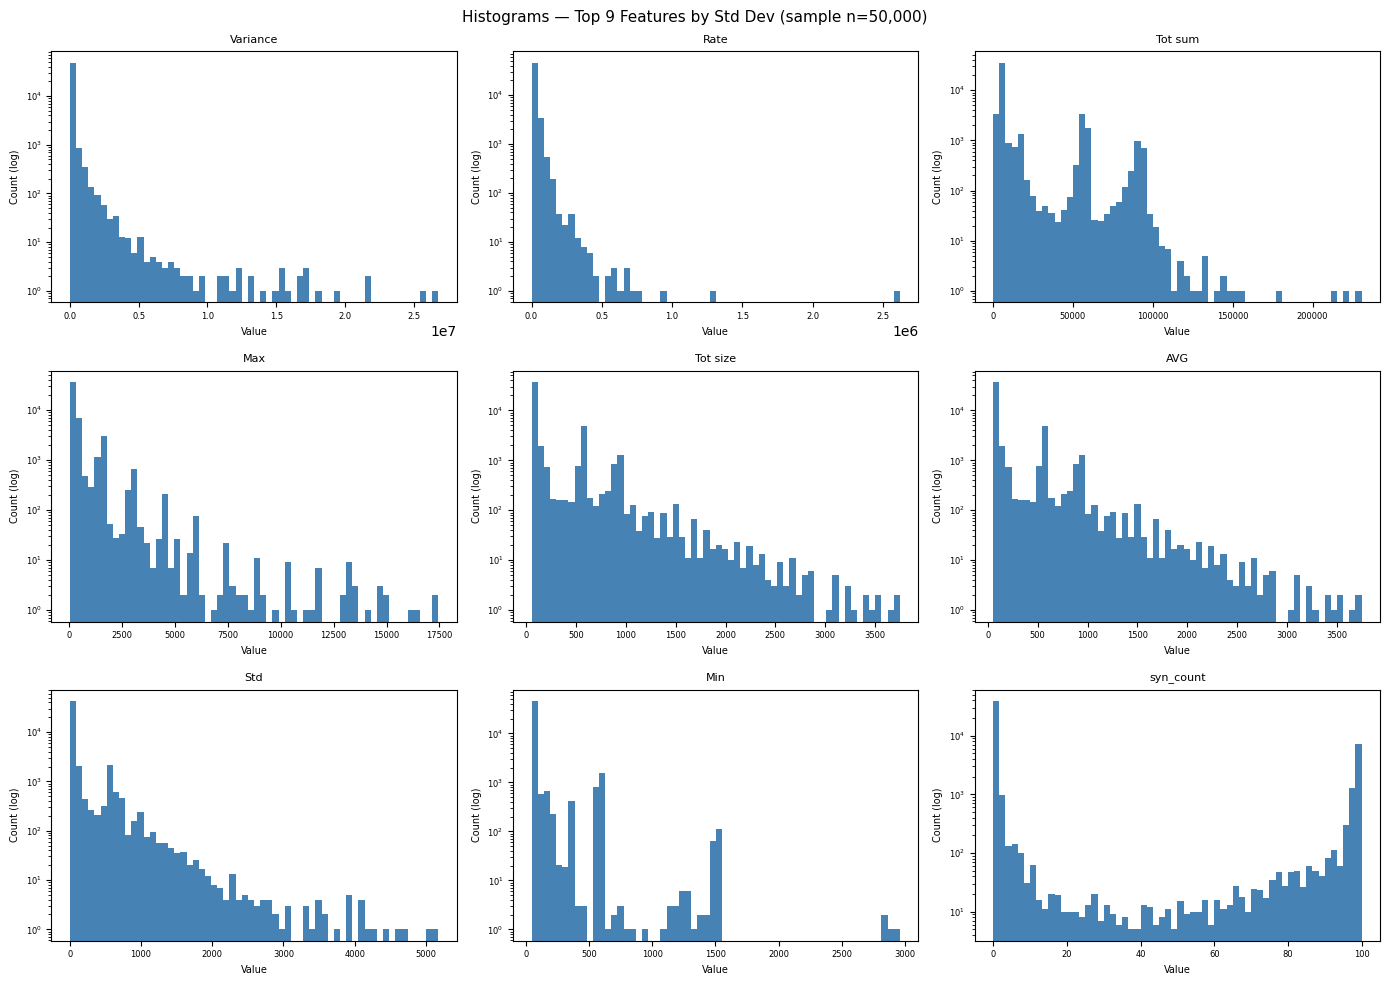

In [63]:
HIST_SAMPLE_N = 50_000
HIST_TOP_N    = 9
 
top_hist_features = (
    numeric_summary["std"]
    .sort_values(ascending=False)
    .head(HIST_TOP_N)
    .index.tolist()
)
 
df_hist = df[top_hist_features].sample(
    n=min(HIST_SAMPLE_N, len(df)), random_state=RANDOM_STATE
)
 
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
 
for ax, col in zip(axes, top_hist_features):
    data = df_hist[col].dropna()
    ax.hist(data, bins=60, color="steelblue", edgecolor="none", log=True)
    ax.set_title(col, fontsize=8)
    ax.set_xlabel("Value", fontsize=7)
    ax.set_ylabel("Count (log)", fontsize=7)
    ax.tick_params(labelsize=6)
 
for ax in axes[len(top_hist_features):]:
    ax.set_visible(False)
 
fig.suptitle(
    f"Histograms — Top {HIST_TOP_N} Features by Std Dev "
    f"(sample n={HIST_SAMPLE_N:,})",
    fontsize=11
)
plt.tight_layout()
plt.show()

## Boxplot Grid - Top 6 Features by Std Dev

Boxplots show spread and extreme values for the highest-variance features. This is useful for spotting outliers before preprocessing.

The code below samples rows and draws boxplots for the features with the largest standard deviation.

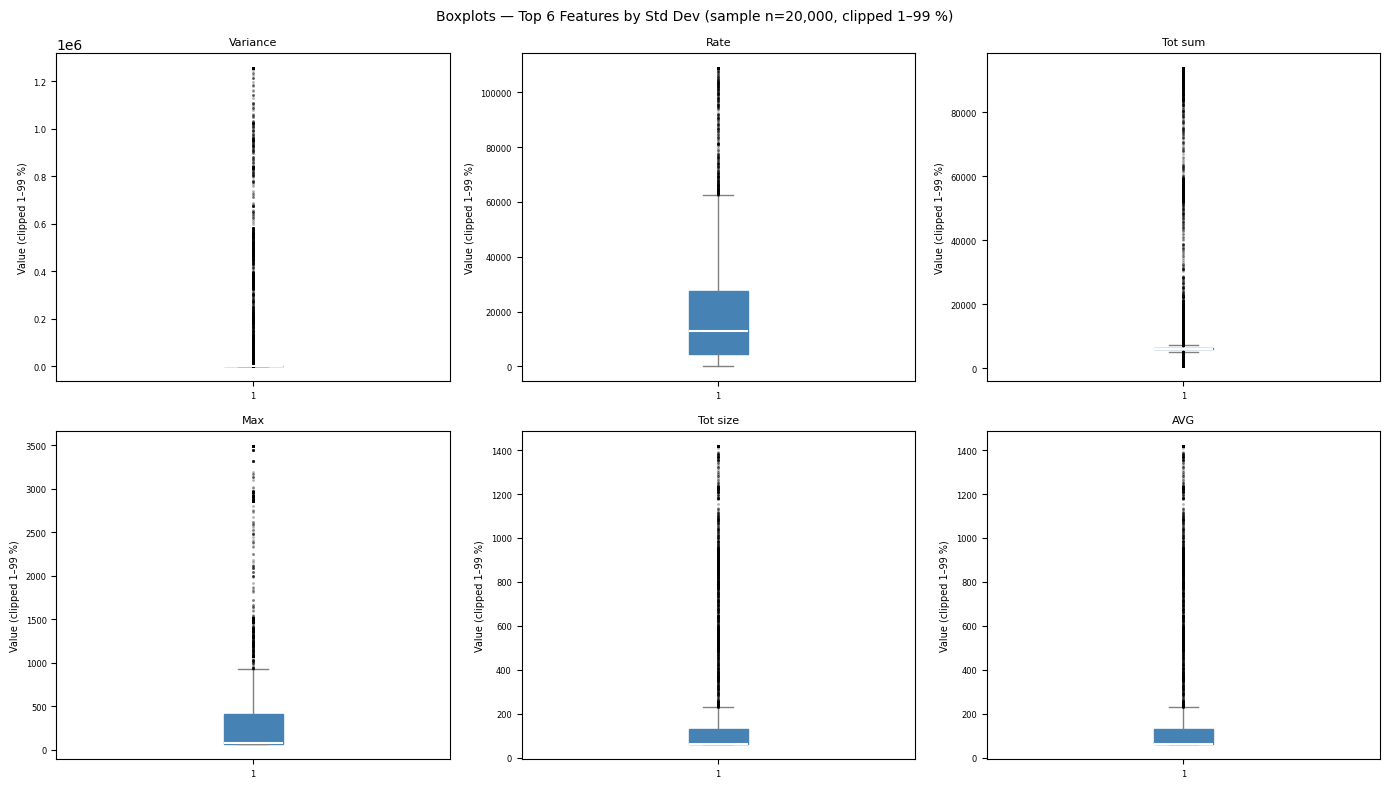

In [64]:
BOX_SAMPLE_N = 20_000
BOX_TOP_N    = 6
 
top_box_features = (
    numeric_summary["std"]
    .sort_values(ascending=False)
    .head(BOX_TOP_N)
    .index.tolist()
)
 
df_box = df[top_box_features].sample(
    n=min(BOX_SAMPLE_N, len(df)), random_state=RANDOM_STATE
)
 
# Clip to 1st–99th percentile so extreme outliers do not squash the boxes
df_box_clipped = df_box.copy()
for col in top_box_features:
    lo = df_box[col].quantile(0.01)
    hi = df_box[col].quantile(0.99)
    df_box_clipped[col] = df_box[col].clip(lo, hi)
 
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
 
for ax, col in zip(axes, top_box_features):
    ax.boxplot(
        df_box_clipped[col].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor="steelblue", color="steelblue"),
        medianprops=dict(color="white", linewidth=1.5),
        whiskerprops=dict(color="gray"),
        capprops=dict(color="gray"),
        flierprops=dict(marker=".", color="gray", alpha=0.3, markersize=2)
    )
    ax.set_title(col, fontsize=8)
    ax.set_ylabel("Value (clipped 1–99 %)", fontsize=7)
    ax.tick_params(labelsize=6)
 
for ax in axes[len(top_box_features):]:
    ax.set_visible(False)
 
fig.suptitle(
    f"Boxplots — Top {BOX_TOP_N} Features by Std Dev "
    f"(sample n={BOX_SAMPLE_N:,}, clipped 1–99 %)",
    fontsize=10
)
plt.tight_layout()
plt.show()

## Correlation Heatmap - Top 20 Features by Std Dev

The heatmap shows which high-variance features move together. Strong correlations can point to redundant features.

The code below samples rows, selects high-variance features, and plots their correlation matrix.

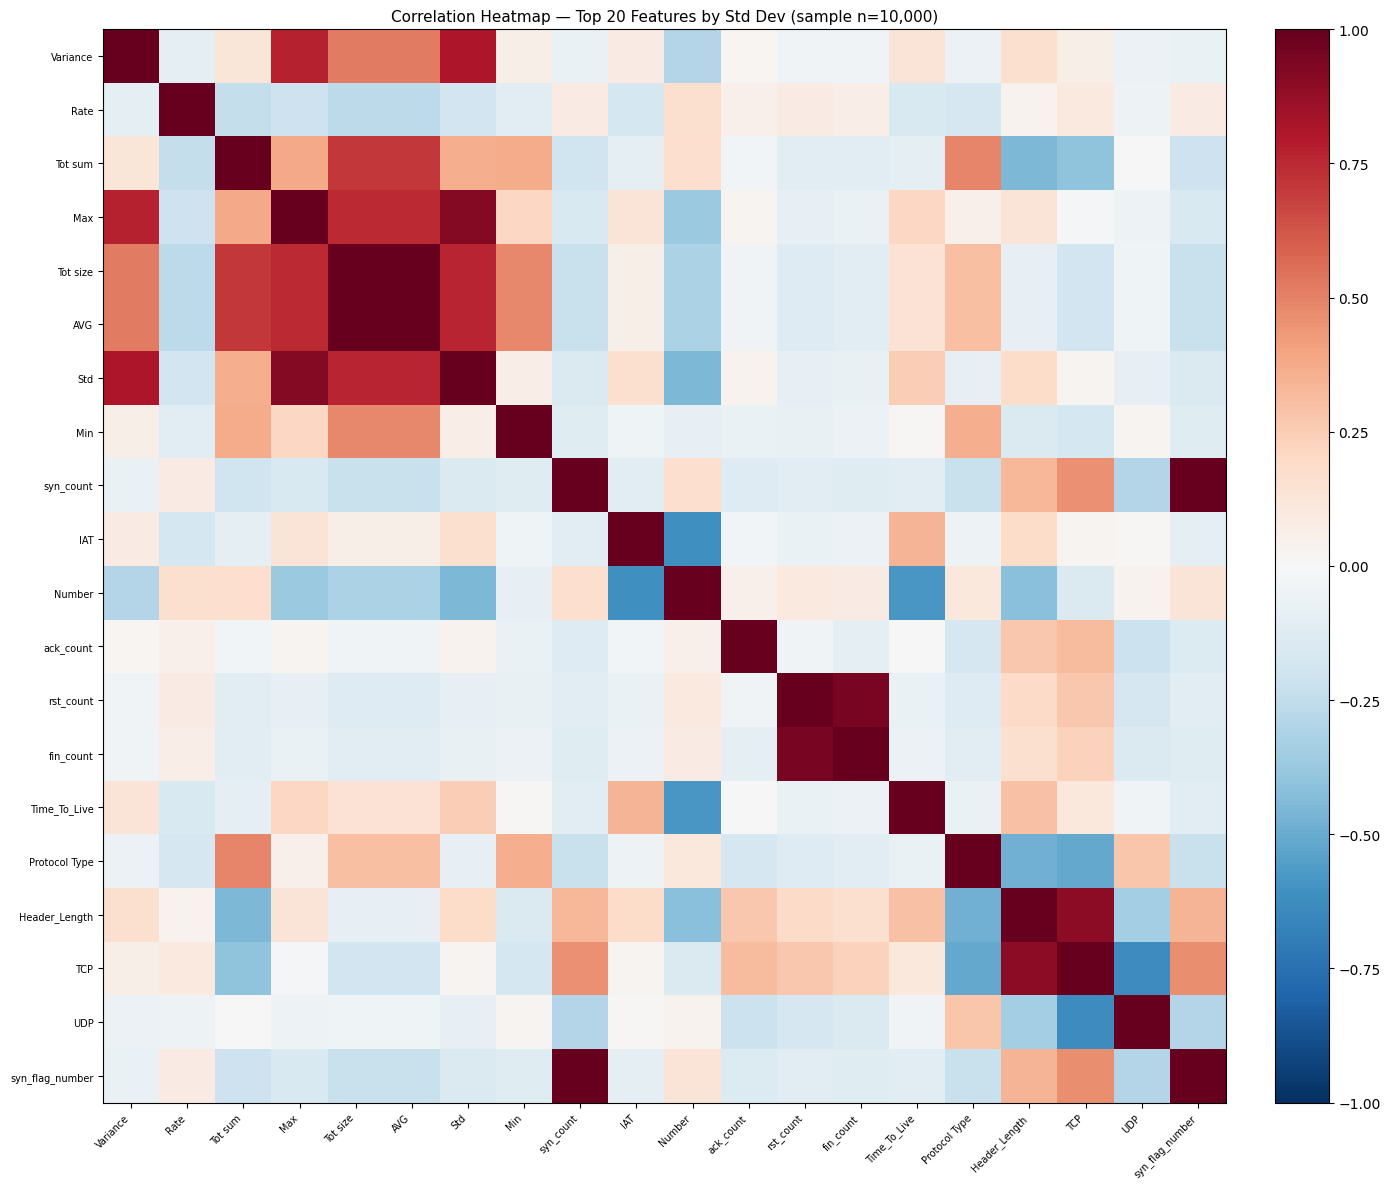

In [65]:
CORR_SAMPLE_N = 10_000
CORR_TOP_N    = 20
 
top_corr_features = (
    numeric_summary["std"]
    .sort_values(ascending=False)
    .head(CORR_TOP_N)
    .index.tolist()
)
 
df_corr_sample = df[top_corr_features].sample(
    n=min(CORR_SAMPLE_N, len(df)), random_state=RANDOM_STATE
)
 
corr_matrix = df_corr_sample.corr()
 
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
 
ax.set_xticks(range(len(top_corr_features)))
ax.set_yticks(range(len(top_corr_features)))
ax.set_xticklabels(top_corr_features, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(top_corr_features, fontsize=7)
 
ax.set_title(
    f"Correlation Heatmap — Top {CORR_TOP_N} Features by Std Dev "
    f"(sample n={CORR_SAMPLE_N:,})",
    fontsize=11
)
plt.tight_layout()
plt.show()

In [66]:
#Clean up for mem usage
to_delete = [
    "top_hist_features", "df_hist",
    "top_box_features",  "df_box", "df_box_clipped",
    "top_corr_features", "df_corr_sample", "corr_matrix", "im"
]
 
for var in to_delete:
    if var in globals():
        del globals()[var]
 
gc.collect()
print("Deleted visualization intermediates.")

Deleted visualization intermediates.


# Step 12 - Metadata and Grouping Column Detection

Check for columns that describe collection context rather than traffic behavior. These columns can leak information or reduce generalization if used as model features.

The code below searches column names for metadata-style keywords and reports any likely matches.

In [67]:
METADATA_KEYWORDS = [
    "time", "timestamp", "date", "epoch",
    "session", "run", "scenario", "capture",
    "origin", "source", "file", "id",
    "index", "seq", "sequence", "order",
]
 
found_metadata = {}
for col in df.columns:
    col_l = col.lower().replace(" ", "_")
    matched = [kw for kw in METADATA_KEYWORDS if kw in col_l]
    if matched:
        found_metadata[col] = matched
 
print("=== COLUMN NAME METADATA SCAN ===")
print(f"Total columns              : {len(df.columns)}")
print(f"All columns                : {df.columns.tolist()}")
print(f"Columns matching keywords  : {len(found_metadata)}")
if found_metadata:
    print()
    for col, kws in found_metadata.items():
        print(f"  '{col}' matched keywords: {kws}")
else:
    print("  -> None found.")

=== COLUMN NAME METADATA SCAN ===
Total columns              : 40
All columns                : ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label']
Columns matching keywords  : 1

  'Time_To_Live' matched keywords: ['time']


In [68]:
# --- datetime types ---
datetime_cols = df.select_dtypes(include=["datetime", "datetimetz"]).columns.tolist()
 
# --- non-label object columns (could be string IDs or timestamps loaded as strings) ---
object_cols_nonlabel = [
    c for c in df.select_dtypes(include=["object"]).columns
    if c != TARGET_COL
]
 
print("=== DTYPE AUDIT FOR METADATA ===")
print(f"datetime columns         : {datetime_cols if datetime_cols else 'None'}")
print(f"Other object columns     : {object_cols_nonlabel if object_cols_nonlabel else 'None'}")
 
# --- monotonically increasing/decreasing columns (ordering proxy) ---
# Use a random sample so this stays fast on the full dataset
sample_order = df.sample(n=min(5_000, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)
 
mono_increasing = []
mono_decreasing = []
 
for col in df.select_dtypes(include=[np.number]).columns:
    if col == TARGET_COL:
        continue
    vals = sample_order[col].dropna().values
    if len(vals) < 10:
        continue
    diffs = np.diff(vals)
    if np.all(diffs >= 0):
        mono_increasing.append(col)
    elif np.all(diffs <= 0):
        mono_decreasing.append(col)
 
print()
print("=== SEQUENTIAL / ORDERING CHECK (sample n=5,000) ===")
print(f"Monotonically increasing columns : {mono_increasing if mono_increasing else 'None'}")
print(f"Monotonically decreasing columns : {mono_decreasing if mono_decreasing else 'None'}")

=== DTYPE AUDIT FOR METADATA ===
datetime columns         : None
Other object columns     : None


C:\Users\user\AppData\Local\Temp\ipykernel_17048\3655472002.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  c for c in df.select_dtypes(include=["object"]).columns



=== SEQUENTIAL / ORDERING CHECK (sample n=5,000) ===
Monotonically increasing columns : None
Monotonically decreasing columns : None


# Step 13 - Rare Class Check and Frequency Tiers

Measure class imbalance and group labels by frequency. This helps us choose a subset that keeps rare classes instead of letting large classes dominate.

The code below assigns each class to a frequency tier based on its row count.

In [69]:
TIER_VERY_FREQUENT = 1_000_000
TIER_MODERATE      =   100_000
TIER_RARE          =    10_000
 
def assign_tier(count):
    if count >= TIER_VERY_FREQUENT:
        return "very_frequent"
    elif count >= TIER_MODERATE:
        return "moderate"
    elif count >= TIER_RARE:
        return "rare"
    else:
        return "extremely_rare"
 
class_dist["tier"] = class_dist["count"].apply(assign_tier)
 
tier_order = ["very_frequent", "moderate", "rare", "extremely_rare"]
tier_colors = {
    "very_frequent":  "crimson",
    "moderate":       "steelblue",
    "rare":           "goldenrod",
    "extremely_rare": "seagreen",
}
 
print("=== CLASS FREQUENCY TIERS ===")
for tier in tier_order:
    subset = class_dist[class_dist["tier"] == tier]
    print(f"\n{tier.upper()} ({len(subset)} classes):")
    for _, row in subset.iterrows():
        print(f"  {row['count']:>10,}  {row['percentage']:6.3f}%  {row['class']}")

=== CLASS FREQUENCY TIERS ===

VERY_FREQUENT (11 classes):
   1,964,069   9.351%  DDOS-UDP_FLOOD
   1,907,549   9.082%  DDOS-ICMP_FLOOD
   1,851,255   8.813%  DOS-UDP_FLOOD
   1,764,592   8.401%  DDOS-SYN_FLOOD
   1,641,896   7.817%  DDOS-PSHACK_FLOOD
   1,560,610   7.430%  DDOS-TCP_FLOOD
   1,255,783   5.979%  DDOS-RSTFINFLOOD
   1,171,372   5.577%  DDOS-SYNONYMOUSIP_FLOOD
   1,138,613   5.421%  DOS-SYN_FLOOD
   1,120,179   5.333%  DOS-TCP_FLOOD
   1,047,308   4.986%  BENIGN

MODERATE (10 classes):
     897,596   4.273%  MIRAI-GREETH_FLOOD
     767,297   3.653%  MIRAI-UDPPLAIN
     694,290   3.305%  MIRAI-GREIP_FLOOD
     431,149   2.053%  DDOS-ICMP_FRAGMENTATION
     356,322   1.696%  VULNERABILITYSCAN
     273,392   1.302%  DDOS-UDP_FRAGMENTATION
     271,535   1.293%  DDOS-ACK_FRAGMENTATION
     269,044   1.281%  MITM-ARPSPOOFING
     167,017   0.795%  DNS_SPOOFING
     127,869   0.609%  RECON-HOSTDISCOVERY

RARE (6 classes):
      92,323   0.440%  RECON-OSSCAN
      76,789   0.366

## Class Frequency Tier Plot

This plot shows how uneven the class counts are. It makes the imbalance easier to read than a long table.

The code below plots class counts with colors based on the frequency tier.

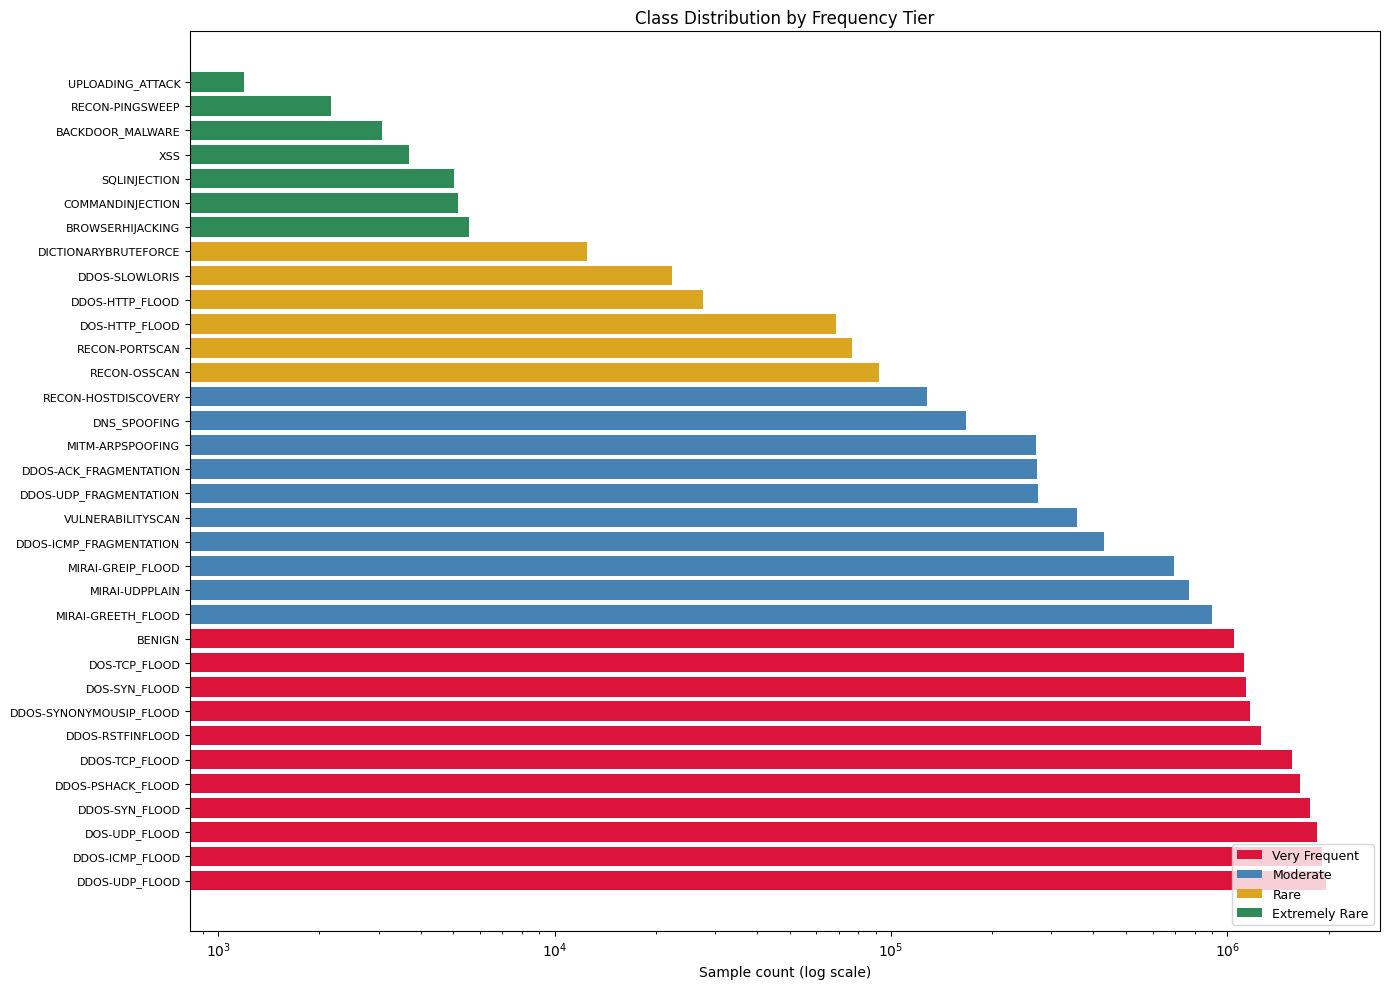

In [70]:
plot_labels  = class_dist["class"].astype(str).tolist()
plot_counts  = class_dist["count"].tolist()
plot_colors  = [tier_colors[t] for t in class_dist["tier"].tolist()]
 
# Sort by count descending for readability
sorted_idx   = class_dist["count"].argsort()[::-1].values
plot_labels  = [plot_labels[i]  for i in sorted_idx]
plot_counts  = [plot_counts[i]  for i in sorted_idx]
plot_colors  = [plot_colors[i]  for i in sorted_idx]
 
fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(range(len(plot_labels)), plot_counts, color=plot_colors)
ax.set_yticks(range(len(plot_labels)))
ax.set_yticklabels(plot_labels, fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("Sample count (log scale)")
ax.set_title("Class Distribution by Frequency Tier")
 
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=tier_colors[t], label=t.replace("_", " ").title())
    for t in tier_order
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
 

 
plt.tight_layout()
plt.show()

In [71]:
#Clean up for mem usage
to_delete = ["flagged", "safe", "sorted_idx",
             "plot_labels", "plot_counts", "plot_colors",
             "bars", "legend_elements", "min_count_line"]
 
for var in to_delete:
    if var in globals():
        del globals()[var]
 
gc.collect()
print("Deleted tier analysis intermediates.")


Deleted tier analysis intermediates.


# Step 14 - Subset Decision Strategy

The full dataset is too large for fast experiments, so we cap each class at a fixed number of rows. This keeps training manageable while preserving every class.

The code below prints the class counts and shows how many rows would be kept under the chosen cap.

In [72]:
TARGET_COL = "Label"

class_counts = df[TARGET_COL].value_counts(dropna=False).sort_values(ascending=False)
class_percent = (class_counts / len(df) * 100).round(4)

class_dist = pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values,
    "percentage": class_percent.values
}).reset_index(drop=True)

class_dist

,class,count,percentage
0,DDOS-UDP_FLOOD,1964069,9.3506
1,DDOS-ICMP_FLOOD,1907549,9.0815
2,DOS-UDP_FLOOD,1851255,8.8135
3,DDOS-SYN_FLOOD,1764592,8.4009
4,DDOS-PSHACK_FLOOD,1641896,7.8168
5,DDOS-TCP_FLOOD,1560610,7.4298
6,DDOS-RSTFINFLOOD,1255783,5.9786
7,DDOS-SYNONYMOUSIP_FLOOD,1171372,5.5767
8,DOS-SYN_FLOOD,1138613,5.4208
9,DOS-TCP_FLOOD,1120179,5.3330


## Applying the Per-Class Cap

For large classes, sample up to the cap. For smaller classes, keep all available rows. A fixed random seed makes the subset reproducible.

The code below samples each large class up to `CAP_PER_CLASS` and keeps smaller classes unchanged.

In [73]:
CAP_PER_CLASS = 50_000
RANDOM_STATE = 42
subset_parts = []

for label, group in df.groupby(TARGET_COL, group_keys=False):
    if len(group) > CAP_PER_CLASS:
        sampled_group = group.sample(n=CAP_PER_CLASS, random_state=RANDOM_STATE)
    else:
        sampled_group = group

    subset_parts.append(sampled_group)

df_subset = pd.concat(subset_parts, ignore_index=True)

print("Original cleaned shape:", df.shape)
print("Subset shape          :", df_subset.shape)

# New class distribution after sampling
subset_class_counts = df_subset[TARGET_COL].value_counts(dropna=False).sort_values(ascending=False)
subset_class_percent = (subset_class_counts / len(df_subset) * 100).round(4)

subset_class_dist = pd.DataFrame({
    "class": subset_class_counts.index,
    "count": subset_class_counts.values,
    "percentage": subset_class_percent.values
}).reset_index(drop=True)

subset_class_dist

Original cleaned shape: (21004674, 40)
Subset shape          : (1288384, 40)


,class,count,percentage
0,BENIGN,50000,3.8808
1,DDOS-ACK_FRAGMENTATION,50000,3.8808
2,DDOS-ICMP_FLOOD,50000,3.8808
3,DDOS-ICMP_FRAGMENTATION,50000,3.8808
4,DDOS-PSHACK_FLOOD,50000,3.8808
5,DDOS-RSTFINFLOOD,50000,3.8808
6,DDOS-SYNONYMOUSIP_FLOOD,50000,3.8808
7,DDOS-SYN_FLOOD,50000,3.8808
8,DDOS-TCP_FLOOD,50000,3.8808
9,DDOS-UDP_FLOOD,50000,3.8808


# Step 15 - Save the Cleaned Subset

Save the final subset to disk so Notebook 2 can start from a clean, smaller dataset without repeating the raw ingestion work.

The code below writes the final subset CSV and prints a quick confirmation of its size and location.

In [74]:
subset_csv_path = SUBSET_DIR / "subset_cleaned.csv"
df_subset.to_csv(subset_csv_path, index=False)

print("Saved sampled cleaned subset to:", subset_csv_path)

Saved sampled cleaned subset to: c:\Users\user\Desktop\MyFiles\Uni\My_ML_Project\data\subset\subset_cleaned.csv
